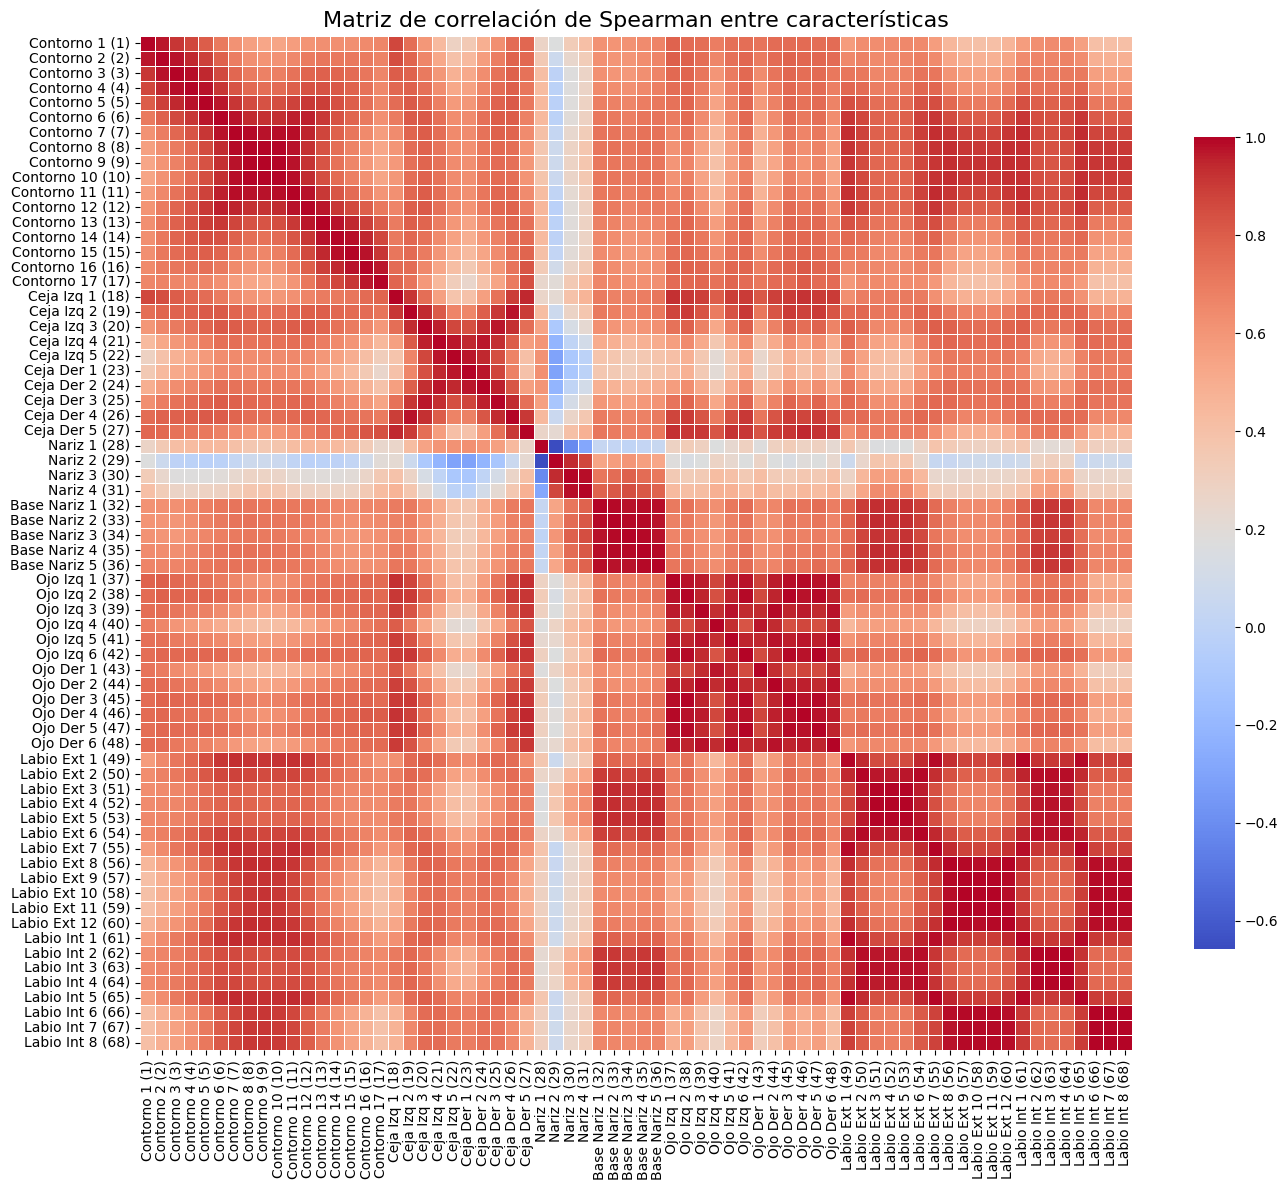

In [1]:
import os
import re
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd  
import seaborn as sns
from scipy.stats import pearsonr, chi2_contingency
from sklearn.preprocessing import KBinsDiscretizer

def ordenar_numerico(valor):
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = list(map(int, partes[1::2]))
    return partes

def leer_datos(ruta_base):
    datos = []
    
    for dir_act, subdirs, archivos in os.walk(ruta_base):
        subdirs[:] = [d for d in subdirs if not d.startswith('.')]
        archivos = [f for f in archivos if not f.startswith('.')]
        subdirs.sort(key=ordenar_numerico)
        archivos.sort(key=ordenar_numerico)
        
        for arch in archivos:
            if arch.endswith('.txt'):
                ruta_arch = os.path.join(dir_act, arch)
                try:
                    with open(ruta_arch, 'r') as f:
                        valor = f.read().strip()
                    try:
                        valor = int(float(valor))
                    except ValueError as e:
                        print(f"Error al convertir el número en {ruta_arch}: {e}")
                        continue

                    dir_rel = os.path.relpath(dir_act, ruta_base)
                    dir_img = os.path.join('cohn-kanade-images', dir_rel)
                    imgs = [f for f in os.listdir(dir_img) if f.endswith('.png')]
                    imgs.sort(key=ordenar_numerico)
                    
                    if imgs:
                        ruta_img_expresion = os.path.join(dir_img, imgs[-1])  
                        datos.append((ruta_img_expresion, valor))
                    else:
                        print(f"No se encontraron imágenes en {dir_img}")
                except Exception as e:
                    print(f"Error leyendo {ruta_arch}: {e}")
    return datos

det = dlib.get_frontal_face_detector()
pred = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

def extraer_puntos(ruta_imagen):
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"No se pudo cargar la imagen {ruta_imagen}")
        return None

    rostros = det(imagen, 1)
    if len(rostros) == 0:
        print(f"No se detectaron rostros en {ruta_imagen}")
        return None

    for rostro in rostros:
        puntos = pred(imagen, rostro)
        lista_puntos = [(puntos.part(n).x, puntos.part(n).y) for n in range(68)]
        return lista_puntos
    return None

def centrar_pts(pts):
    ojo_izq = np.mean(pts[36:42], axis=0)
    ojo_der = np.mean(pts[42:48], axis=0)
    punto_central = (ojo_izq + ojo_der) / 2
    pts_centrados = pts - punto_central
    return pts_centrados

def extraer_landmarks(datos):
    lista_pts = []
    lista_emo = []
    lista_ruta_img_expresion = []
    
    for item in datos:
        if len(item) != 2:
            print(f"Elemento ignorado: formato inesperado {item}")
            continue

        ruta_img_expresion, emo = item
        pts_expresion = extraer_puntos(ruta_img_expresion)

        if pts_expresion is not None:
            pts_expresion = np.array(pts_expresion)
            pts_expresion_centrados = centrar_pts(pts_expresion)
            lista_pts.append(pts_expresion_centrados) 
            lista_emo.append(emo)
            lista_ruta_img_expresion.append(ruta_img_expresion)
        else:
            print(f"No se pudieron extraer puntos de {ruta_img_expresion}")

    if not lista_pts:
        print("No se extrajeron puntos faciales.")
        return None, None, None

    X = np.array(lista_pts)  # X(n_samples, 68, 2)
    y = np.array(lista_emo)
    return X, y, lista_ruta_img_expresion

ruta_base = 'Emotion'
datos = leer_datos(ruta_base)
X, y, paths_expresion = extraer_landmarks(datos)

X_magnitudes = np.linalg.norm(X, axis=2) 
X_magnitudes_68 = X_magnitudes[:, :68]

feature_names = [
    "Contorno 1 (1)", "Contorno 2 (2)", "Contorno 3 (3)", "Contorno 4 (4)", "Contorno 5 (5)", 
    "Contorno 6 (6)", "Contorno 7 (7)", "Contorno 8 (8)", "Contorno 9 (9)", "Contorno 10 (10)",
    "Contorno 11 (11)", "Contorno 12 (12)", "Contorno 13 (13)", "Contorno 14 (14)", "Contorno 15 (15)", 
    "Contorno 16 (16)", "Contorno 17 (17)", 

    "Ceja Izq 1 (18)", "Ceja Izq 2 (19)", "Ceja Izq 3 (20)", "Ceja Izq 4 (21)", "Ceja Izq 5 (22)",  

    "Ceja Der 1 (23)", "Ceja Der 2 (24)", "Ceja Der 3 (25)", "Ceja Der 4 (26)", "Ceja Der 5 (27)",  

    "Nariz 1 (28)", "Nariz 2 (29)", "Nariz 3 (30)", "Nariz 4 (31)", 

    "Base Nariz 1 (32)", "Base Nariz 2 (33)", "Base Nariz 3 (34)", "Base Nariz 4 (35)", "Base Nariz 5 (36)",  

    "Ojo Izq 1 (37)", "Ojo Izq 2 (38)", "Ojo Izq 3 (39)", "Ojo Izq 4 (40)", "Ojo Izq 5 (41)", "Ojo Izq 6 (42)",  

    "Ojo Der 1 (43)", "Ojo Der 2 (44)", "Ojo Der 3 (45)", "Ojo Der 4 (46)", "Ojo Der 5 (47)", "Ojo Der 6 (48)",  

    "Labio Ext 1 (49)", "Labio Ext 2 (50)", "Labio Ext 3 (51)", "Labio Ext 4 (52)", "Labio Ext 5 (53)", "Labio Ext 6 (54)", 
    "Labio Ext 7 (55)", "Labio Ext 8 (56)", "Labio Ext 9 (57)", "Labio Ext 10 (58)", "Labio Ext 11 (59)", "Labio Ext 12 (60)",  

    "Labio Int 1 (61)", "Labio Int 2 (62)", "Labio Int 3 (63)", "Labio Int 4 (64)", "Labio Int 5 (65)", "Labio Int 6 (66)", 
    "Labio Int 7 (67)", "Labio Int 8 (68)" 
]

df_features = pd.DataFrame(X_magnitudes_68, columns=feature_names)

corr_matrix = df_features.corr(method='spearman')

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, 
            annot=False,
            cmap='coolwarm', 
            linewidths=0.5, 
            fmt=".2f", 
            xticklabels=feature_names, 
            yticklabels=feature_names,
            cbar_kws={"shrink": .8})
plt.title('Matriz de correlación de Spearman entre características', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


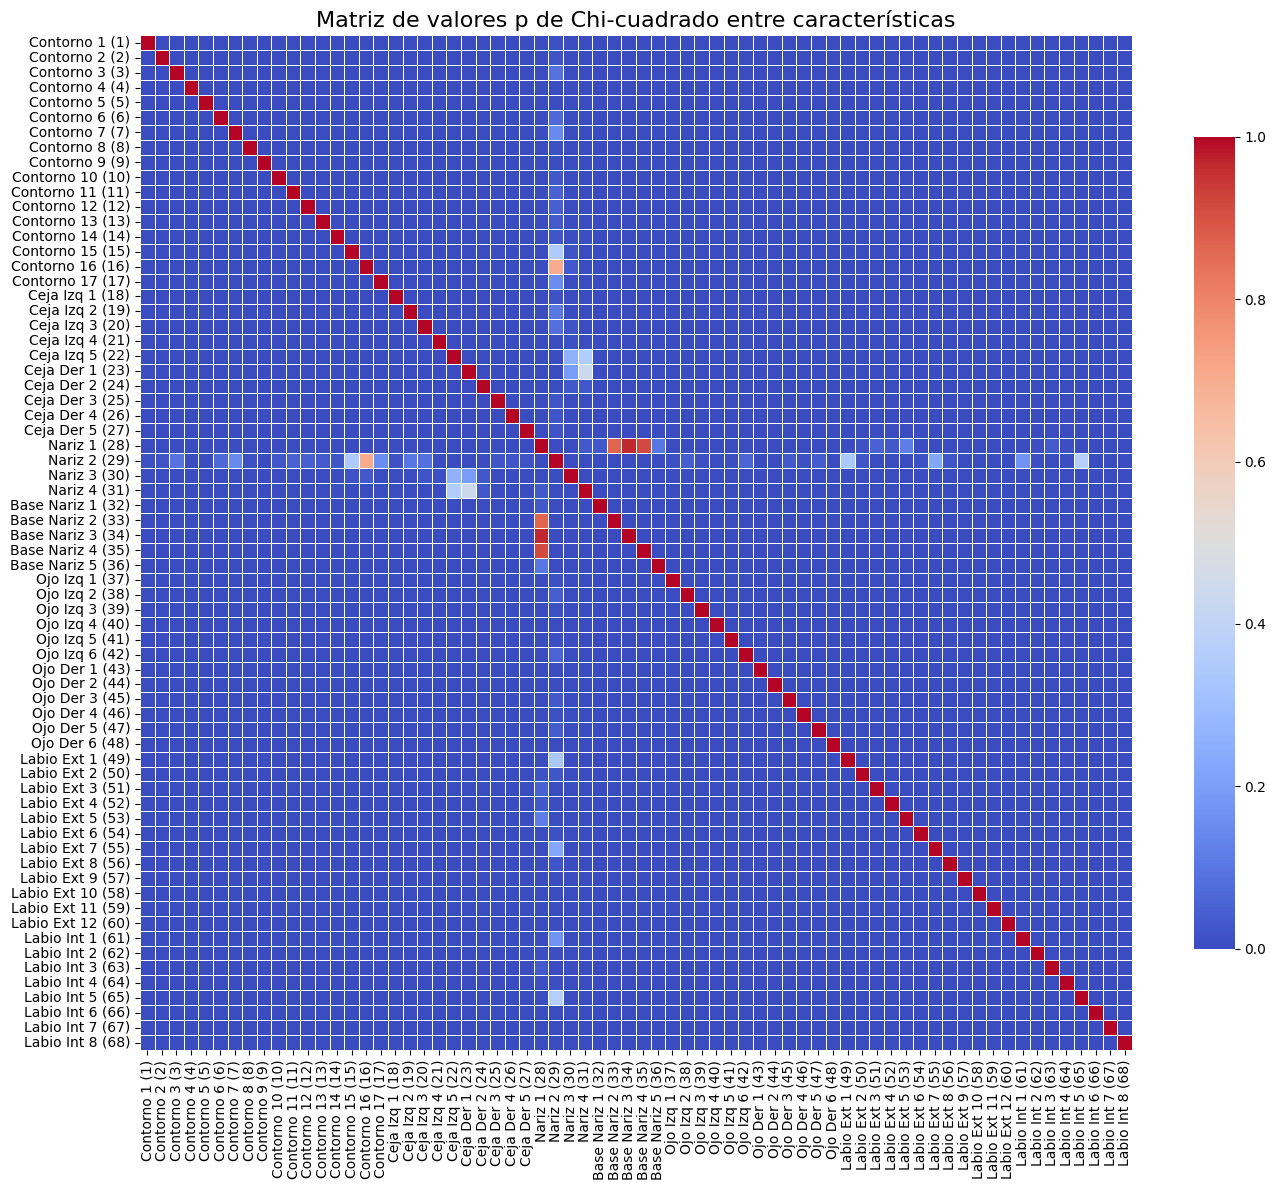

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import KBinsDiscretizer
from scipy.stats import chi2_contingency

# Discretizador en 5 bins
discretizer = KBinsDiscretizer(
    n_bins=5, 
    encode='ordinal', 
    strategy='uniform'
)
X_discretized = discretizer.fit_transform(X_magnitudes_68)

# Crear matriz para guardar p-values
n_features = X_discretized.shape[1]
chi2_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        if i != j:
            # Construir la tabla de contingencia
            contingency_table = pd.crosstab(
                X_discretized[:, i], 
                X_discretized[:, j]
            )
            chi2_val, p_val, dof, expected = chi2_contingency(contingency_table)
            chi2_matrix[i, j] = p_val
        else:
            # Por convención, la diagonal la ponemos a 1 
            # (o podrías poner np.nan si prefieres)
            chi2_matrix[i, j] = 1.0

# Convertir a DataFrame para visualización
chi2_df = pd.DataFrame(
    chi2_matrix, 
    columns=feature_names, 
    index=feature_names
)

plt.figure(figsize=(14, 12))
sns.heatmap(chi2_df, 
            annot=False,
            cmap='coolwarm', 
            linewidths=0.5, 
            fmt=".2f", 
            xticklabels=feature_names, 
            yticklabels=feature_names,
            cbar_kws={"shrink": .8})
plt.title('Matriz de valores p de Chi-cuadrado entre características', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import KBinsDiscretizer
from scipy.stats import chi2_contingency

# Lista de nombres de las características (68 landmarks)
feature_names = [
    "Contorno 1 (1)", "Contorno 2 (2)", "Contorno 3 (3)", "Contorno 4 (4)", "Contorno 5 (5)", 
    "Contorno 6 (6)", "Contorno 7 (7)", "Contorno 8 (8)", "Contorno 9 (9)", "Contorno 10 (10)",
    "Contorno 11 (11)", "Contorno 12 (12)", "Contorno 13 (13)", "Contorno 14 (14)", "Contorno 15 (15)", 
    "Contorno 16 (16)", "Contorno 17 (17)", 

    "Ceja Izq 1 (18)", "Ceja Izq 2 (19)", "Ceja Izq 3 (20)", "Ceja Izq 4 (21)", "Ceja Izq 5 (22)",  

    "Ceja Der 1 (23)", "Ceja Der 2 (24)", "Ceja Der 3 (25)", "Ceja Der 4 (26)", "Ceja Der 5 (27)",  

    "Nariz 1 (28)", "Nariz 2 (29)", "Nariz 3 (30)", "Nariz 4 (31)", 

    "Base Nariz 1 (32)", "Base Nariz 2 (33)", "Base Nariz 3 (34)", "Base Nariz 4 (35)", "Base Nariz 5 (36)",  

    "Ojo Izq 1 (37)", "Ojo Izq 2 (38)", "Ojo Izq 3 (39)", "Ojo Izq 4 (40)", "Ojo Izq 5 (41)", "Ojo Izq 6 (42)",  

    "Ojo Der 1 (43)", "Ojo Der 2 (44)", "Ojo Der 3 (45)", "Ojo Der 4 (46)", "Ojo Der 5 (47)", "Ojo Der 6 (48)",  

    "Labio Ext 1 (49)", "Labio Ext 2 (50)", "Labio Ext 3 (51)", "Labio Ext 4 (52)", "Labio Ext 5 (53)", "Labio Ext 6 (54)", 
    "Labio Ext 7 (55)", "Labio Ext 8 (56)", "Labio Ext 9 (57)", "Labio Ext 10 (58)", "Labio Ext 11 (59)", "Labio Ext 12 (60)",  

    "Labio Int 1 (61)", "Labio Int 2 (62)", "Labio Int 3 (63)", "Labio Int 4 (64)", "Labio Int 5 (65)", "Labio Int 6 (66)", 
    "Labio Int 7 (67)", "Labio Int 8 (68)" 
]

# Discretizador en 5 bins
discretizer = KBinsDiscretizer(
    n_bins=5, 
    encode='ordinal', 
    strategy='uniform'
)

# Ajustar el discretizador y transformar los datos
X_discretized = discretizer.fit_transform(X_magnitudes_68)

# Crear la matriz para guardar los p-values
n_features = X_discretized.shape[1]
chi2_matrix = np.zeros((n_features, n_features))

# Calcular la prueba Chi-cuadrado para cada par de características
for i in range(n_features):
    for j in range(n_features):
        if i != j:
            # Construir la tabla de contingencia
            contingency_table = pd.crosstab(
                X_discretized[:, i], 
                X_discretized[:, j]
            )
            chi2_val, p_val, dof, expected = chi2_contingency(contingency_table)
            chi2_matrix[i, j] = p_val
        else:
            # En la diagonal ponemos 1 (o np.nan si lo prefieres)
            chi2_matrix[i, j] = 1.0

# Convertir a DataFrame para una mejor visualización
chi2_df = pd.DataFrame(
    chi2_matrix, 
    columns=feature_names, 
    index=feature_names
)

# Graficar la matriz de valores p
plt.figure(figsize=(14, 12))
sns.heatmap(chi2_df, 
            annot=False,
            cmap='coolwarm', 
            linewidths=0.5, 
            fmt=".2f", 
            xticklabels=feature_names, 
            yticklabels=feature_names,
            cbar_kws={"shrink": .8})
plt.title('Matriz de valores p de Chi-cuadrado entre características', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


ValueError: Shape of passed values is (3, 3), indices imply (68, 68)